# Atividade — Análise e Processamento de Imagens

**Objetivo:** analisar três imagens: uma escura, uma clara/saturada e uma bem exposta.  
Para cada imagem serão realizados:

1. Conversão para tons de cinza;
2. Plotagem e análise do histograma;
3. Aplicação de uma única operação de processamento;
4. Comparação entre antes e depois;
5. Análise dos histogramas antes e depois.

As operações utilizadas podem ser:
- Expansão de contraste;
- Equalização do histograma;
- Correção de gamma.

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

## 1. Definição das imagens

Nesta atividade serão utilizadas três fotografias:

- **Imagem 1:** fotografia escura demais;
- **Imagem 2:** fotografia clara demais ou saturada;
- **Imagem 3:** fotografia considerada bem exposta.

Substitua os nomes abaixo pelos nomes dos seus arquivos.

In [14]:
# Nomes dos arquivos das três imagens
arquivo_escura = "IMG1.jpg"
arquivo_clara = "IMG2.jpg"
arquivo_bem_exposta = "IMG3.jpg"

# Verificação dos arquivos
for arquivo in [arquivo_escura, arquivo_clara, arquivo_bem_exposta]:
    if not Path(arquivo).exists():
        print(f"Arquivo não encontrado: {arquivo}")
    else:
        print(f"Arquivo encontrado: {arquivo}")

Arquivo encontrado: IMG1.jpg
Arquivo encontrado: IMG2.jpg
Arquivo encontrado: IMG3.jpg


## 2. Funções auxiliares

As funções abaixo realizam:
- leitura das imagens;
- conversão para tons de cinza;
- cálculo e exibição do histograma;
- expansão de contraste;
- equalização do histograma;
- correção de gamma.

In [15]:
def carregar_imagem(caminho):
    imagem = cv2.imread(caminho)

    if imagem is None:
        raise ValueError(f"Não foi possível abrir a imagem: {caminho}")

    # OpenCV lê em BGR, então convertemos para RGB
    imagem = cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)

    return imagem


def converter_cinza(imagem):
    return cv2.cvtColor(imagem, cv2.COLOR_RGB2GRAY)


def calcular_histograma(imagem_cinza):
    hist = cv2.calcHist(
        [imagem_cinza],
        [0],
        None,
        [256],
        [0, 256]
    )

    return hist


def expandir_contraste(imagem_cinza, L=20, H=235):
    imagem = imagem_cinza.astype(np.float32)

    imagem_expandida = (imagem - L) * (255 / (H - L))

    # Limita os valores entre 0 e 255
    imagem_expandida = np.clip(imagem_expandida, 0, 255)

    return imagem_expandida.astype(np.uint8)


def equalizar_histograma(imagem_cinza):
    return cv2.equalizeHist(imagem_cinza)


def corrigir_gamma(imagem_cinza, gamma=1.0):
    # Cria uma tabela de transformação
    tabela = np.array([
        ((i / 255.0) ** (1 / gamma)) * 255
        for i in np.arange(256)
    ]).astype(np.uint8)

    return cv2.LUT(imagem_cinza, tabela)

## 3. Carregamento das imagens

Agora as três fotografias são carregadas e convertidas para tons de cinza.

In [16]:
# Carregar imagens
imagem_escura = carregar_imagem(arquivo_escura)
imagem_clara = carregar_imagem(arquivo_clara)
imagem_bem_exposta = carregar_imagem(arquivo_bem_exposta)

# Converter para tons de cinza
cinza_escura = converter_cinza(imagem_escura)
cinza_clara = converter_cinza(imagem_clara)
cinza_bem_exposta = converter_cinza(imagem_bem_exposta)

print("Imagens carregadas e convertidas para tons de cinza.")

Imagens carregadas e convertidas para tons de cinza.


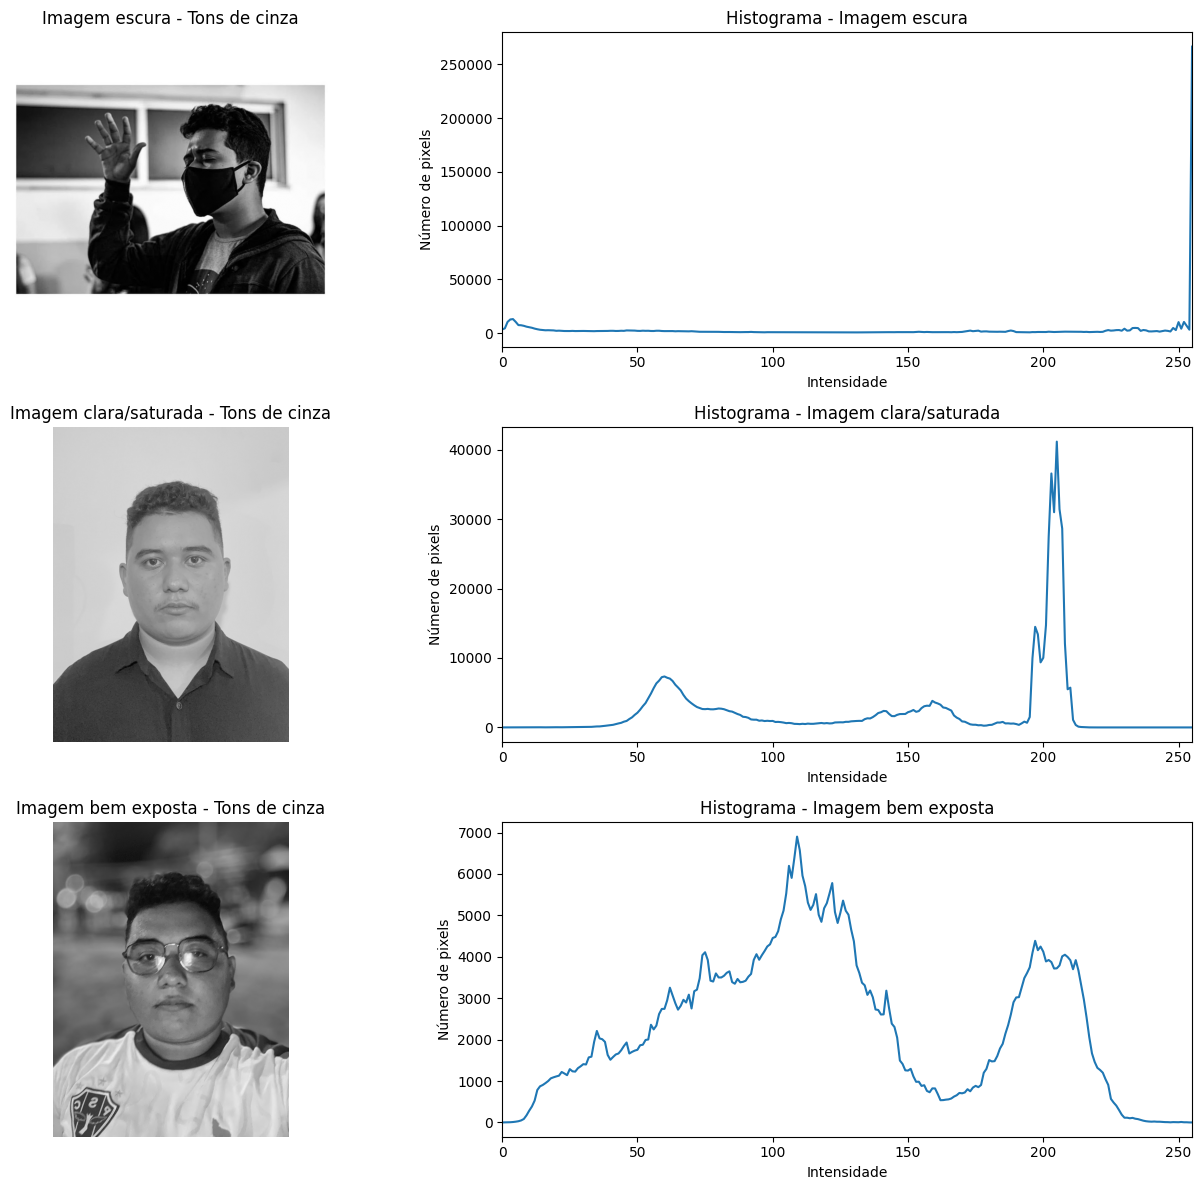

In [17]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# Imagem escura
axes[0, 0].imshow(cinza_escura, cmap="gray")
axes[0, 0].set_title("Imagem escura - Tons de cinza")
axes[0, 0].axis("off")

axes[0, 1].plot(calcular_histograma(cinza_escura))
axes[0, 1].set_title("Histograma - Imagem escura")
axes[0, 1].set_xlim([0, 255])
axes[0, 1].set_xlabel("Intensidade")
axes[0, 1].set_ylabel("Número de pixels")

# Imagem clara
axes[1, 0].imshow(cinza_clara, cmap="gray")
axes[1, 0].set_title("Imagem clara/saturada - Tons de cinza")
axes[1, 0].axis("off")

axes[1, 1].plot(calcular_histograma(cinza_clara))
axes[1, 1].set_title("Histograma - Imagem clara/saturada")
axes[1, 1].set_xlim([0, 255])
axes[1, 1].set_xlabel("Intensidade")
axes[1, 1].set_ylabel("Número de pixels")

# Imagem bem exposta
axes[2, 0].imshow(cinza_bem_exposta, cmap="gray")
axes[2, 0].set_title("Imagem bem exposta - Tons de cinza")
axes[2, 0].axis("off")

axes[2, 1].plot(calcular_histograma(cinza_bem_exposta))
axes[2, 1].set_title("Histograma - Imagem bem exposta")
axes[2, 1].set_xlim([0, 255])
axes[2, 1].set_xlabel("Intensidade")
axes[2, 1].set_ylabel("Número de pixels")

plt.tight_layout()
plt.show()

## 4. Diagnóstico da imagem escura

O histograma da imagem escura está concentrado principalmente nas regiões de baixa intensidade, próximas ao lado esquerdo do gráfico. Isso indica predominância de tons escuros e caracteriza uma imagem subexposta, com possível perda de detalhes nas regiões de sombra.

## 5. Diagnóstico da imagem clara/saturada

O histograma da imagem clara/saturada está concentrado principalmente nas regiões de alta intensidade, próximas ao lado direito do gráfico. Isso indica predominância de tons claros e pode caracterizar uma imagem superexposta, com possível perda de detalhes nas regiões muito claras.

## 6. Diagnóstico da imagem bem exposta

O histograma da imagem bem exposta apresenta uma distribuição mais equilibrada ao longo da faixa de intensidades. Isso indica maior variedade de tons e uma exposição mais adequada, com menor concentração excessiva nas regiões de sombra ou de altas luzes.

## 7. Processamento da imagem escura

### Operação escolhida: Correção de Gamma

Para a imagem escura será utilizada a **correção de gamma**, com:

**γ = 0,60**

A escolha é adequada porque valores de gamma menores que 1 aumentam a intensidade dos tons médios, tornando a imagem visualmente mais clara e permitindo evidenciar detalhes que estavam pouco visíveis nas regiões escuras.

In [18]:
gamma_escura = 0.60

escura_depois = corrigir_gamma(cinza_escura, gamma_escura)

print(f"Correção de gamma aplicada na imagem escura.")
print(f"Parâmetro usado: γ = {gamma_escura}")

Correção de gamma aplicada na imagem escura.
Parâmetro usado: γ = 0.6


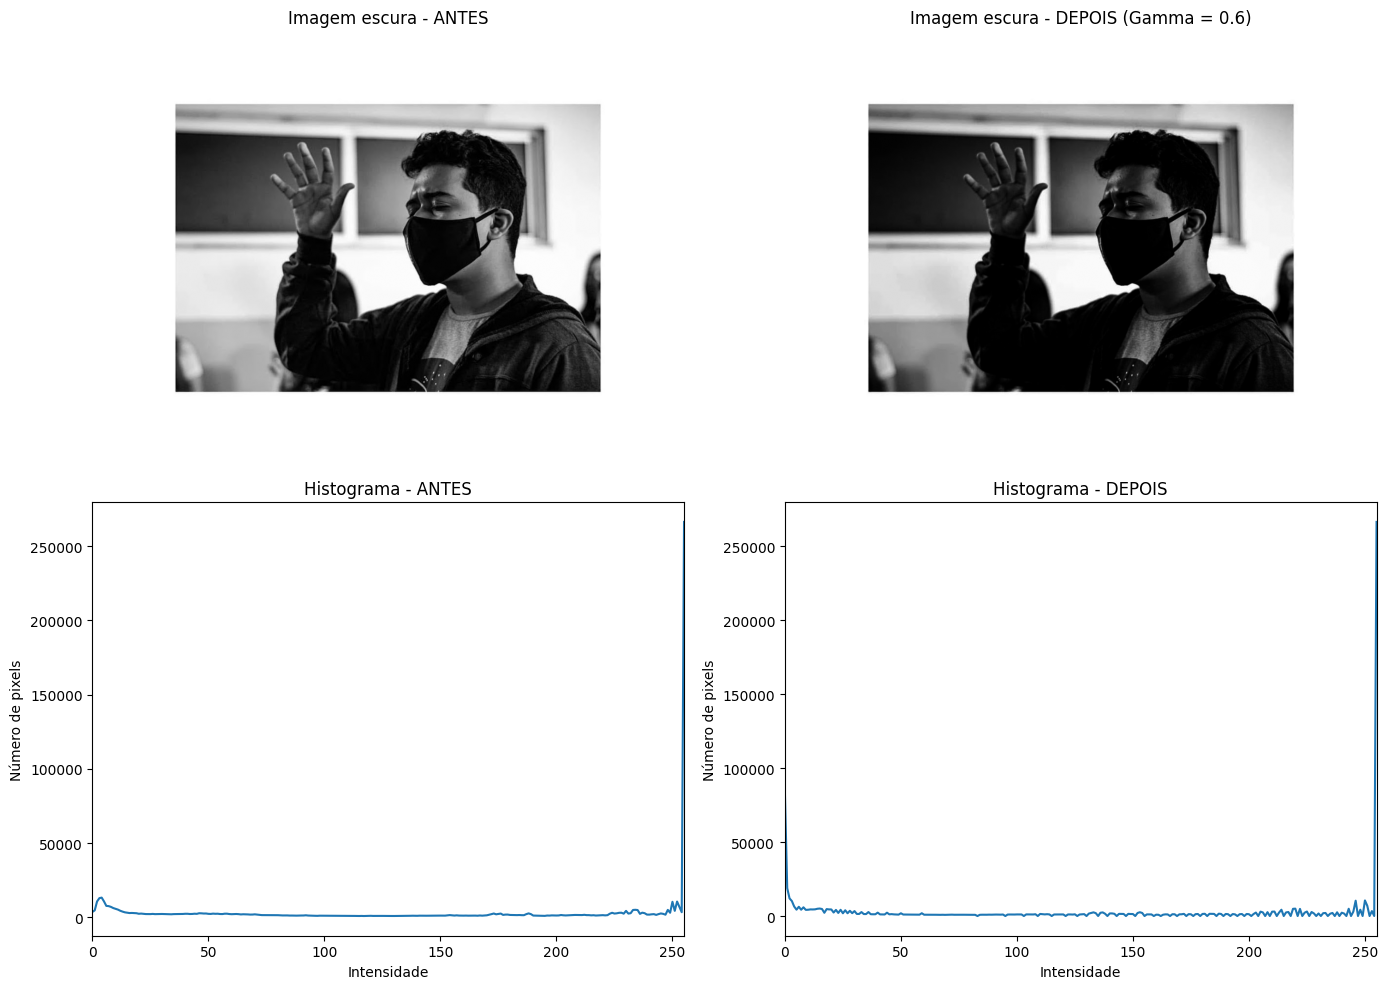

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Antes
axes[0, 0].imshow(cinza_escura, cmap="gray")
axes[0, 0].set_title("Imagem escura - ANTES")
axes[0, 0].axis("off")

# Depois
axes[0, 1].imshow(escura_depois, cmap="gray")
axes[0, 1].set_title(f"Imagem escura - DEPOIS (Gamma = {gamma_escura})")
axes[0, 1].axis("off")

# Histograma antes
axes[1, 0].plot(calcular_histograma(cinza_escura))
axes[1, 0].set_title("Histograma - ANTES")
axes[1, 0].set_xlim([0, 255])
axes[1, 0].set_xlabel("Intensidade")
axes[1, 0].set_ylabel("Número de pixels")

# Histograma depois
axes[1, 1].plot(calcular_histograma(escura_depois))
axes[1, 1].set_title("Histograma - DEPOIS")
axes[1, 1].set_xlim([0, 255])
axes[1, 1].set_xlabel("Intensidade")
axes[1, 1].set_ylabel("Número de pixels")

plt.tight_layout()
plt.show()

### Análise do resultado — imagem escura

Após a correção de gamma, os tons médios da imagem foram deslocados para intensidades maiores. Visualmente, a imagem ficou mais clara e houve maior destaque dos detalhes presentes nas regiões que anteriormente estavam muito escuras.

## 8. Processamento da imagem clara/saturada

### Operação escolhida: Correção de Gamma

Para a imagem clara/saturada será utilizada a **correção de gamma**, com:

**γ = 1,60**

A escolha é adequada porque valores de gamma maiores que 1 reduzem as intensidades dos tons médios, fazendo com que a imagem fique mais escura e equilibrando parte do excesso de luminosidade.

**Observação:** quando uma região está completamente saturada em 255, os detalhes originalmente perdidos nessa região não podem ser recuperados apenas pela correção de gamma.

In [20]:
gamma_clara = 1.60

clara_depois = corrigir_gamma(cinza_clara, gamma_clara)

print(f"Correção de gamma aplicada na imagem clara.")
print(f"Parâmetro usado: γ = {gamma_clara}")

Correção de gamma aplicada na imagem clara.
Parâmetro usado: γ = 1.6


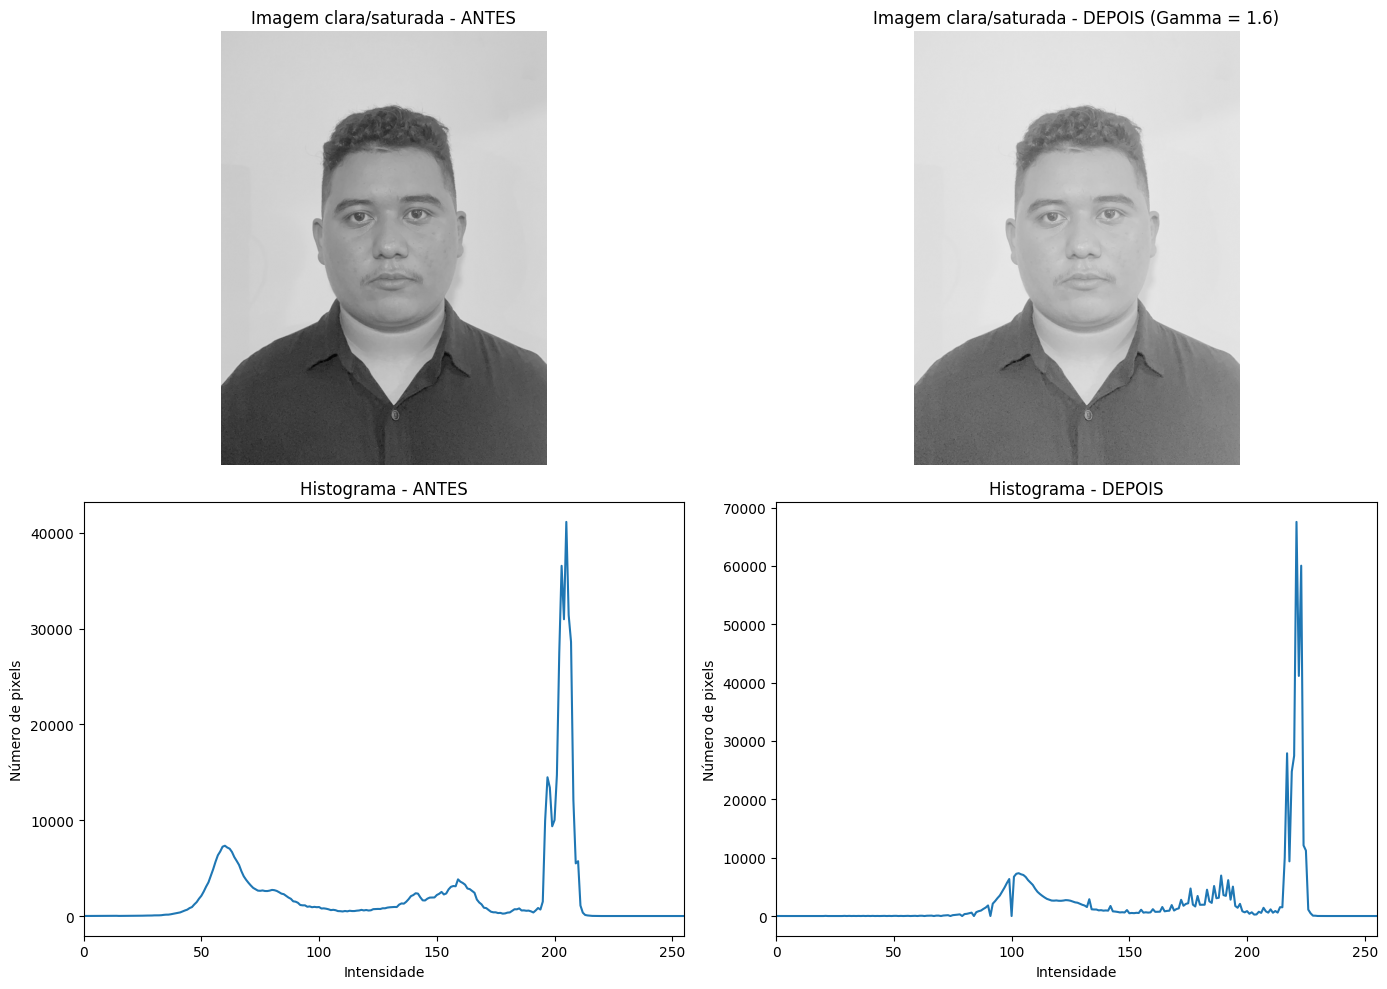

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Antes
axes[0, 0].imshow(cinza_clara, cmap="gray")
axes[0, 0].set_title("Imagem clara/saturada - ANTES")
axes[0, 0].axis("off")

# Depois
axes[0, 1].imshow(clara_depois, cmap="gray")
axes[0, 1].set_title(f"Imagem clara/saturada - DEPOIS (Gamma = {gamma_clara})")
axes[0, 1].axis("off")

# Histograma antes
axes[1, 0].plot(calcular_histograma(cinza_clara))
axes[1, 0].set_title("Histograma - ANTES")
axes[1, 0].set_xlim([0, 255])
axes[1, 0].set_xlabel("Intensidade")
axes[1, 0].set_ylabel("Número de pixels")

# Histograma depois
axes[1, 1].plot(calcular_histograma(clara_depois))
axes[1, 1].set_title("Histograma - DEPOIS")
axes[1, 1].set_xlim([0, 255])
axes[1, 1].set_xlabel("Intensidade")
axes[1, 1].set_ylabel("Número de pixels")

plt.tight_layout()
plt.show()

### Análise do resultado — imagem clara/saturada

Após a correção de gamma, houve redução das intensidades dos tons médios, tornando a imagem menos clara. O histograma também apresentou deslocamento para valores menores de intensidade, embora regiões originalmente saturadas possam continuar sem detalhes.

## 9. Processamento da imagem bem exposta

### Operação escolhida: Expansão de contraste

Para a imagem bem exposta será utilizada a **expansão de contraste**, com:

**L = 20**  
**H = 235**

A escolha foi feita para ampliar a faixa de intensidades utilizada pela imagem, aumentando a separação entre tons escuros e claros. Como a imagem já apresenta uma exposição adequada, espera-se uma alteração mais sutil em comparação com as duas imagens problemáticas.

In [22]:
L = 20
H = 235

bem_exposta_depois = expandir_contraste(
    cinza_bem_exposta,
    L=L,
    H=H
)

print("Expansão de contraste aplicada.")
print(f"L = {L}")
print(f"H = {H}")

Expansão de contraste aplicada.
L = 20
H = 235


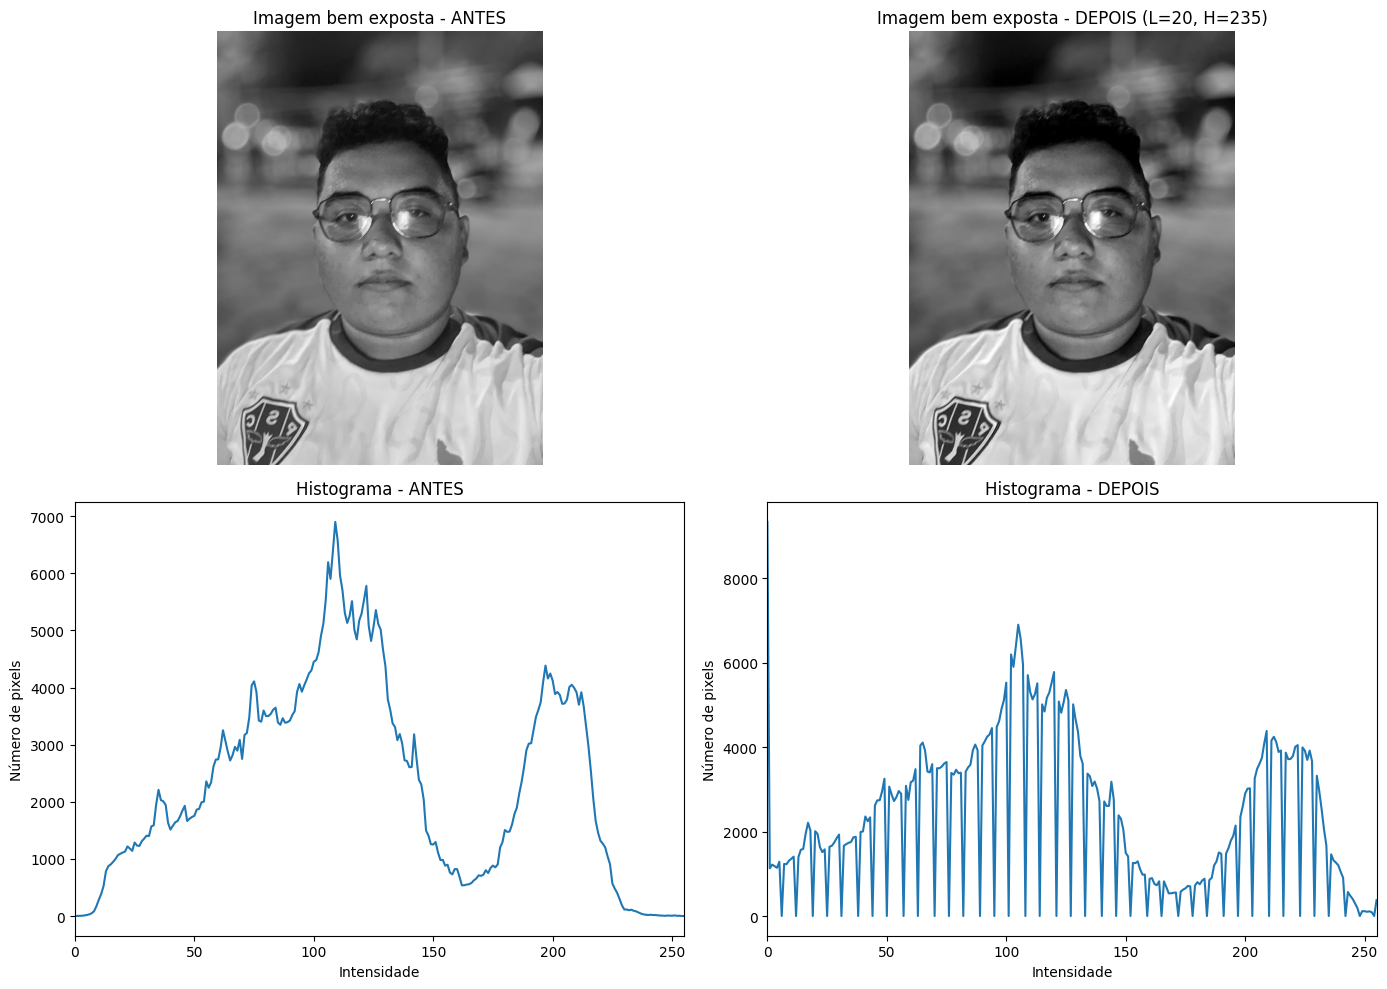

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Antes
axes[0, 0].imshow(cinza_bem_exposta, cmap="gray")
axes[0, 0].set_title("Imagem bem exposta - ANTES")
axes[0, 0].axis("off")

# Depois
axes[0, 1].imshow(bem_exposta_depois, cmap="gray")
axes[0, 1].set_title(f"Imagem bem exposta - DEPOIS (L={L}, H={H})")
axes[0, 1].axis("off")

# Histograma antes
axes[1, 0].plot(calcular_histograma(cinza_bem_exposta))
axes[1, 0].set_title("Histograma - ANTES")
axes[1, 0].set_xlim([0, 255])
axes[1, 0].set_xlabel("Intensidade")
axes[1, 0].set_ylabel("Número de pixels")

# Histograma depois
axes[1, 1].plot(calcular_histograma(bem_exposta_depois))
axes[1, 1].set_title("Histograma - DEPOIS")
axes[1, 1].set_xlim([0, 255])
axes[1, 1].set_xlabel("Intensidade")
axes[1, 1].set_ylabel("Número de pixels")

plt.tight_layout()
plt.show()

### Análise do resultado — imagem bem exposta

A expansão de contraste aumentou a utilização da faixa de intensidades da imagem. Como a fotografia já apresentava uma exposição adequada, a alteração visual foi relativamente pequena, ocorrendo principalmente na distribuição dos tons e no aumento da diferença entre regiões claras e escuras.

## 10. Comparação das três imagens

Para auxiliar a comparação, será calculada a diferença média absoluta entre a imagem original e a imagem processada.

Quanto menor esse valor, menor foi a alteração numérica provocada pela operação.

In [24]:
def diferenca_media(imagem_antes, imagem_depois):
    diferenca = np.abs(
        imagem_antes.astype(np.float32) -
        imagem_depois.astype(np.float32)
    )

    return np.mean(diferenca)


dif_escura = diferenca_media(cinza_escura, escura_depois)
dif_clara = diferenca_media(cinza_clara, clara_depois)
dif_bem_exposta = diferenca_media(cinza_bem_exposta, bem_exposta_depois)

print(f"Imagem escura:       {dif_escura:.2f}")
print(f"Imagem clara:        {dif_clara:.2f}")
print(f"Imagem bem exposta:  {dif_bem_exposta:.2f}")

Imagem escura:       15.65
Imagem clara:        28.00
Imagem bem exposta:  8.53


In [25]:
diferencas = {
    "Imagem escura": dif_escura,
    "Imagem clara/saturada": dif_clara,
    "Imagem bem exposta": dif_bem_exposta
}

imagem_menor_diferenca = min(
    diferencas,
    key=diferencas.get
)

print("Imagem em que a operação fez menos diferença:")
print(imagem_menor_diferenca)
print(f"Diferença média absoluta: {diferencas[imagem_menor_diferenca]:.2f}")

Imagem em que a operação fez menos diferença:
Imagem bem exposta
Diferença média absoluta: 8.53


## 11. Resposta final

Entre as três imagens, a operação fez menos diferença na **imagem bem exposta**. Isso ocorre porque ela já apresentava uma distribuição de intensidades mais equilibrada e, portanto, não precisava de uma correção tão intensa quanto as imagens escura e clara/saturada. A expansão de contraste produziu apenas uma alteração moderada na distribuição dos tons, enquanto as outras imagens necessitaram de modificações maiores para compensar os efeitos da subexposição ou da superexposição.